In [2]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import xarray as xr
import proplot as pplt
warnings.filterwarnings('ignore')

In [3]:
with open('../scripts/configs.json','r',encoding='utf-8') as f:
    CONFIGS = json.load(f)
SPLITSDIR  = CONFIGS['filepaths']['splits']
MODELSDIR  = CONFIGS['filepaths']['models']
WEIGHTSDIR = CONFIGS['filepaths']['weights']
MODELS     = CONFIGS['experiments']
NNCONFIG   = MODELS['nn']
SPLIT      = 'valid'
DRYTHRESH  = 1.0
VARLABELS  = {
    'bl':'$B_L$ (m/s$^2$)',
    'cape':'$CAPE_L$ (K)',
    'subsat':'$SUBSAT_L$ (K)',
    'rh':'RH (%)',
    'thetae':r'$\mathit{\theta_{e}}$ (K)',
    'thetaestar':r'$\mathit{\theta_{e}}^*$ (K)',
    'lf':'Land Fraction',
    'shf':'Surface Sensible Heat Flux (W/m$^2$)',
    'lhf':'Surface Latent Heat Flux (W/m$^2$)'}

In [ ]:
filepath = os.path.join(WEIGHTSDIR,f'{name}_{seed}_weights.nc')

ds = xr.open_dataset(filepath) as ds

In [14]:
weights = {}
for name in NNCONFIG['runs']:
    if 'param' in name:
        for seed in NNCONFIG['seeds']:
            filepath = os.path.join(WEIGHTSDIR,f'{name}_{seed}_weights.nc')
            if os.path.exists(filepath):
                with xr.open_dataset(filepath) as ds:
                    print(ds)
            # predtp = ds.tp.load()
#         ytrue,ypred = xr.align(truetp,predtp,join='inner')
#         results[name] = (ytrue,ypred)
# print(f'Found {len(results)} models with kernel weights!')

<xarray.Dataset>
Dimensions:  (field: 3, sig: 11, seed: 1)
Coordinates:
  * field    (field) object 'rh' 'thetae' 'thetaestar'
  * sig      (sig) float32 0.5 0.55 0.6 0.65 0.7 0.75 0.8 0.85 0.9 0.95 1.0
  * seed     (seed) int64 0
Data variables:
    k        (field, sig, seed) float32 ...
<xarray.Dataset>
Dimensions:  (field: 3, sig: 11, seed: 1)
Coordinates:
  * field    (field) object 'rh' 'thetae' 'thetaestar'
  * sig      (sig) float32 0.5 0.55 0.6 0.65 0.7 0.75 0.8 0.85 0.9 0.95 1.0
  * seed     (seed) int64 0
Data variables:
    k        (field, sig, seed) float32 ...
<xarray.Dataset>
Dimensions:  (field: 3, sig: 11, seed: 1)
Coordinates:
  * field    (field) object 'rh' 'thetae' 'thetaestar'
  * sig      (sig) float32 0.5 0.55 0.6 0.65 0.7 0.75 0.8 0.85 0.9 0.95 1.0
  * seed     (seed) int64 0
Data variables:
    k        (field, sig, seed) float32 ...
<xarray.Dataset>
Dimensions:  (field: 3, sig: 11, seed: 1)
Coordinates:
  * field    (field) object 'rh' 'thetae' 'thetaestar'


In [6]:
MODELS['nn']

{'projectname': 'Chapter-3-Experiments',
 'seeds': [42, 72, 102],
 'workers': 8,
 'epochs': 20,
 'batchsize': 500,
 'learningrate': 0.0005,
 'patience': 4,
 'criterion': 'MSELoss',
 'runs': {'base_bl': {'kind': 'baseline',
   'fieldvars': ['bl'],
   'localvars': []},
  'base_cape_subsat': {'kind': 'baseline',
   'fieldvars': ['cape', 'subsat'],
   'localvars': []},
  'base_thetae_thetaestar': {'kind': 'baseline',
   'fieldvars': ['thetae', 'thetaestar'],
   'localvars': []},
  'base_thetae_thetaestar_lf': {'kind': 'baseline',
   'fieldvars': ['thetae', 'thetaestar'],
   'localvars': ['lf']},
  'base_thetae_thetaestar_shf_lhf': {'kind': 'baseline',
   'fieldvars': ['thetae', 'thetaestar'],
   'localvars': ['shf', 'lhf']},
  'base_rh': {'kind': 'baseline', 'fieldvars': ['rh'], 'localvars': []},
  'base_rh_lf': {'kind': 'baseline', 'fieldvars': ['rh'], 'localvars': ['lf']},
  'base_rh_shf_lhf': {'kind': 'baseline',
   'fieldvars': ['rh'],
   'localvars': ['shf', 'lhf']},
  'base_all': {'k

In [4]:
weightslist = []
for seed in NNCONFIG['seeds']:
    filepath = os.path.join(WEIGHTSDIR,f'{weightsfrom}_{seed}_weights.nc')
    with xr.open_dataset(filepath,engine='h5netcdf') as ds:
        weightslist.append(ds.k.isel(seed=0).load())
results = xr.concat(weightslist,dim='seed').mean('seed')
results

NameError: name 'weightsfrom' is not defined

In [ ]:
def _load_kernel_weights(weightsfrom):
    weightslist = []
    for seed in NNCONFIG['seeds']:
        filepath = os.path.join(WEIGHTSDIR,f'{weightsfrom}_{seed}_weights.nc')
        with xr.open_dataset(filepath,engine='h5netcdf') as ds:
            weightslist.append(ds.k.isel(seed=0).load())
    return xr.concat(weightslist,dim='seed').mean('seed')
    

In [5]:
def get_kind(name):
    for group in ['pod','nn','sr']:
        runs = MODELS.get(group,{}).get('runs',{})
        if name in runs:
            if group in ('pod','sr'):
                return group
            return runs[name]['kind']
    return 'unknown'

def get_global_range(results):
    allvals = []
    for ytrue,ypred in results.values():
        allvals.append(ytrue.values.ravel())
        allvals.append(ypred.values.ravel())
    allvals = np.concatenate(allvals)
    allvals = allvals[np.isfinite(allvals)&(allvals>0)]
    return allvals.min(),allvals.max()


def _load_kernel_weights(weightsfrom):
    weightslist = []
    for seed in NNCONFIG['seeds']:
        filepath = os.path.join(WEIGHTSDIR,f'{weightsfrom}_{seed}_weights.nc')
        with xr.open_dataset(filepath,engine='h5netcdf') as ds:
            weightslist.append(ds.k.isel(seed=0).load())
    return xr.concat(weightslist,dim='seed').mean('seed')
    

def plot_weights(results):
    for name,(_,_) in results.items():
        runconfig = NNCONFIG['runs'].get(name)
        if runconfig is None or runconfig['kind'] not in ('nonparametric','parametric'):
            continue
        fieldvars = runconfig['fieldvars']
        wdatasets = []
        for seed in NNCONFIG['seeds']:
            filepath = os.path.join(WEIGHTSDIR,f'{name}_{seed}_weights.nc')
            if os.path.exists(filepath):
                wdatasets.append(xr.open_dataset(filepath).load())
        if not wdatasets:
            print(f'No weights found for {name}')
            continue
        weights = xr.concat(wdatasets,dim='seed').assign_coords(seed=np.arange(len(wdatasets)))
        sigs    = weights.sig.values
        fig,axs = pplt.subplots(nrows=1,ncols=len(fieldvars),refheight=2,refwidth=1,share=True)
        axs.format(suptitle=f'{name}',grid=True,xlabel='Normalized Kernel Weight',ylabel='$\\sigma$')
        axs = np.atleast_1d(axs).ravel()
        for ax,varname in zip(axs,fieldvars):
            wmean = weights.k.sel(field=varname).mean('seed').values
            wstd  = weights.k.sel(field=varname).std('seed').values
            ax.plot(wmean,sigs,color='k',linewidth=1.5,label='Sum')
            ax.fill_betweenx(sigs,wmean-wstd,wmean+wstd,color='k',alpha=0.2)
            ax.axvline(0,color='k',linewidth=0.8,linestyle='--')
            ax.format(title=VARLABELS.get(varname,varname),xlim=(-1.5,5.5),yreverse=True,ylim=(1,0.5))
        pplt.show()




In [6]:
def get_predictors(name):
    for group in ['pod','nn','sr']:
        runs = MODELS.get(group,{}).get('runs',{})
        if name in runs:
            rc = runs[name]
            return rc.get('fieldvars',[]),rc.get('localvars',[])
    return [],[]



In [7]:
with xr.open_dataset(os.path.join(SPLITSDIR,f'{SPLIT}.h5'),engine='h5netcdf') as ds:
    truetp = ds.tp.load()

results = {}
for group in ['pod','nn','sr']:
    for name in MODELS[group]['runs']:
        filepath = os.path.join(PREDSDIR,f'{name}_{SPLIT}_predictions.nc')
        if os.path.exists(filepath):
            with xr.open_dataset(filepath) as ds:
                predtp = ds.tp.load()
            ytrue,ypred = xr.align(truetp,predtp,join='inner')
            results[name] = (ytrue,ypred)
print(f'Found {len(results)} models with kernel weights!')

Found 13 models with predictions!
tp range: [2.98e-08, 1.15e+03]


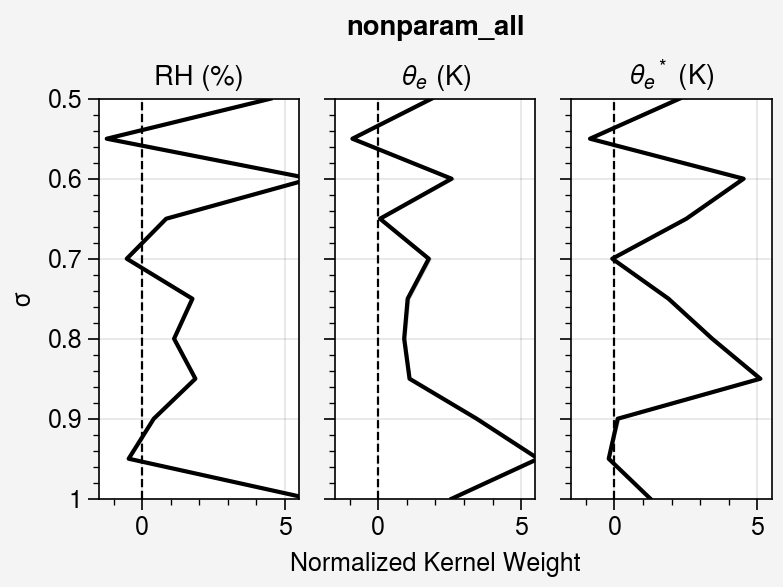

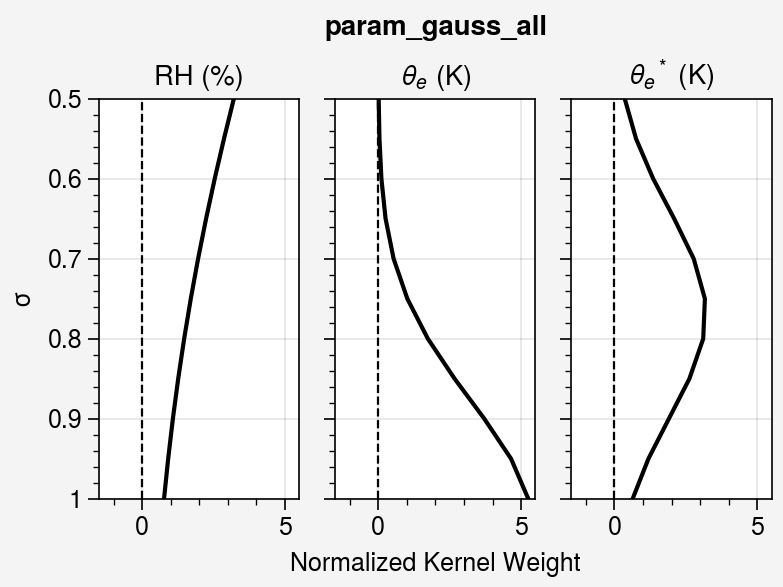

In [14]:
plot_weights(results)